# **1. Perkenalan Dataset**


Dataset yang digunakan adalah **Mall Customer Segmentation** yang diperoleh dari Kaggle.

**Sumber Dataset:**
https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

**Deskripsi Dataset:**  
Dataset ini berisi informasi pelanggan sebuah mall dengan 200 baris dan 5 kolom:
- CustomerID — ID unik pelanggan
- Gender — Jenis kelamin (Male/Female)  
- Age — Usia pelanggan
- Annual Income (k$) — Pendapatan tahunan
- Spending Score (1-100) — Skor pengeluaran

**Tujuan:**  
Mengelompokkan pelanggan menggunakan K-Means Clustering untuk memahami segmentasi pelanggan.

# **2. Import Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("Semua library berhasil diimport!")
print(f"Pandas versi    : {pd.__version__}")
print(f"NumPy versi     : {np.__version__}")
print(f"Seaborn versi   : {sns.__version__}")

Semua library berhasil diimport!
Pandas versi    : 2.2.2
NumPy versi     : 2.0.2
Seaborn versi   : 0.13.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
# Setup Kaggle credentials
from google.colab import files
import os
import shutil

print("Silakan upload file kaggle.json:")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download dataset
!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python --unzip -p ./mall_customers_raw

print("Dataset berhasil didownload!")

Silakan upload file kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
100% 1.55k/1.55k [00:00<00:00, 8.39MB/s]

Dataset berhasil didownload!


In [4]:
# Load dataset
df = pd.read_csv('./mall_customers_raw/Mall_Customers.csv')

print(f"Shape dataset : {df.shape}")
print(f"Kolom         : {list(df.columns)}")
print()
df.head(10)

Shape dataset : (200, 5)
Kolom         : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# Info dataset
print("=" * 50)
print("INFO DATASET")
print("=" * 50)
df.info()
print()
print("=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
df.describe()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

STATISTIK DESKRIPTIF


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
# Cek missing values dan duplikasi
print("Missing Values per Kolom:")
print(df.isnull().sum())
print()
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print()
print("Distribusi Gender:")
print(df['Gender'].value_counts())

Missing Values per Kolom:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Jumlah baris duplikat: 0

Distribusi Gender:
Gender
Female    112
Male       88
Name: count, dtype: int64


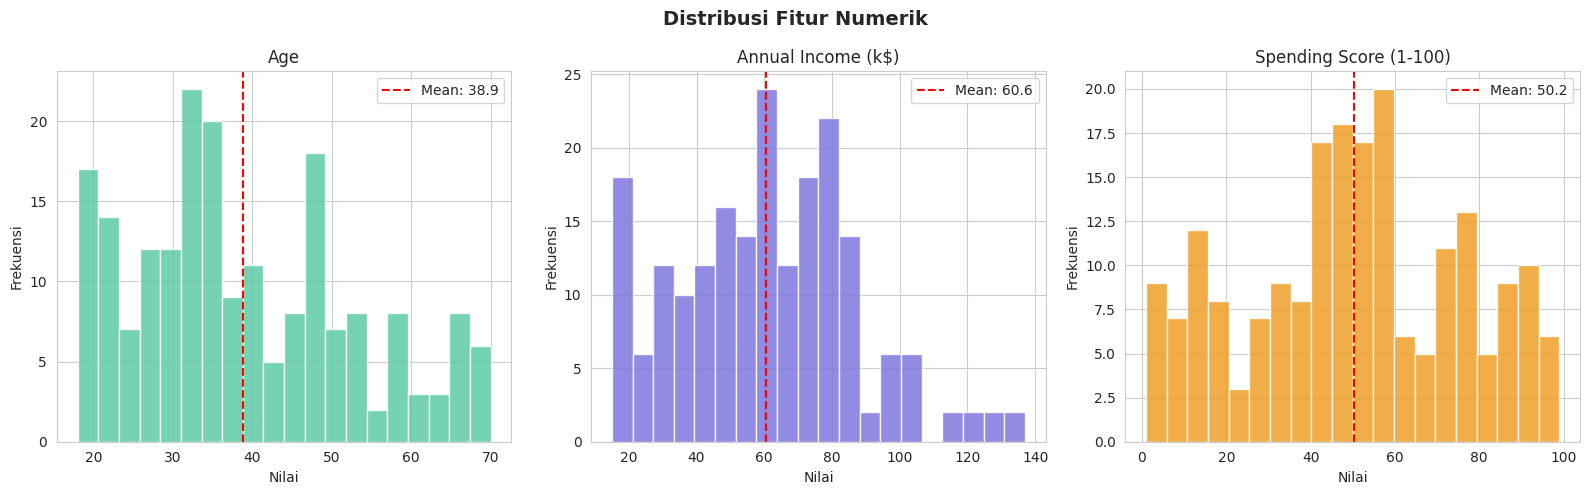

In [7]:
numerical_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['#5DCAA5', '#7F77DD', '#EF9F27']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, numerical_cols, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

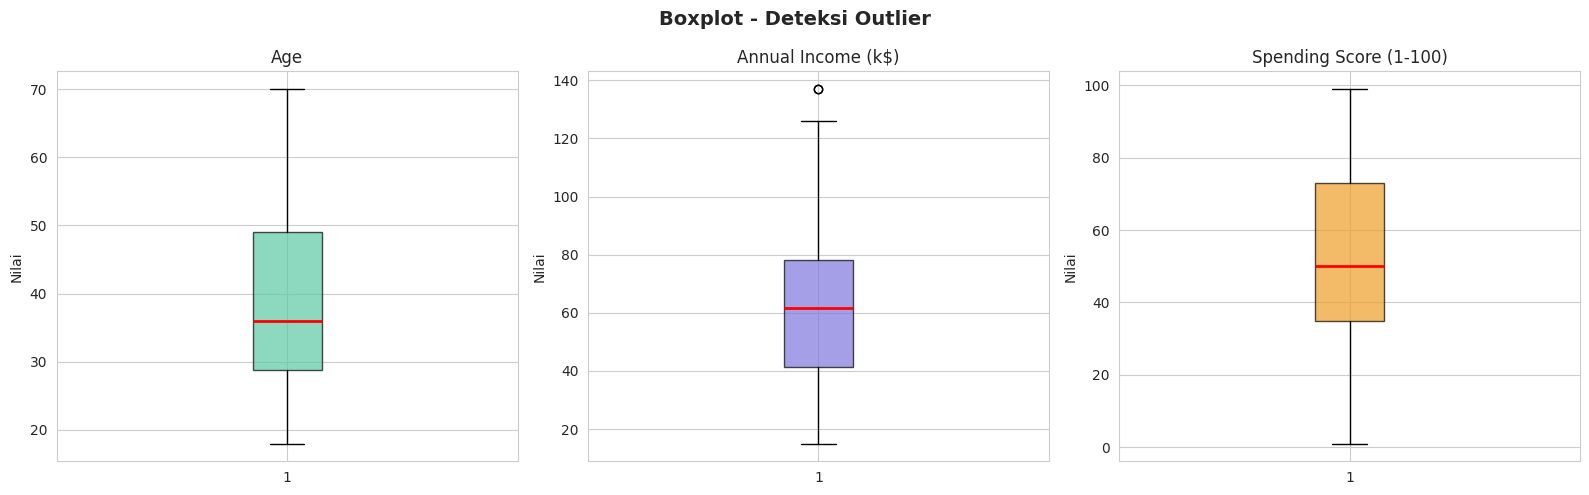

In [8]:
# Boxplot - Deteksi Outlier
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplot - Deteksi Outlier', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, numerical_cols, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col)
    ax.set_ylabel('Nilai')

plt.tight_layout()
plt.show()

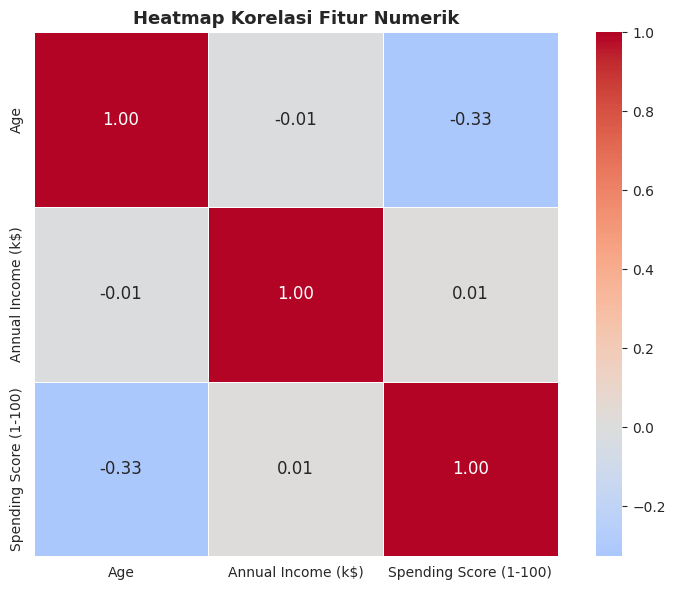

In [9]:
# Heatmap Korelasi
plt.figure(figsize=(8, 6))
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 12})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

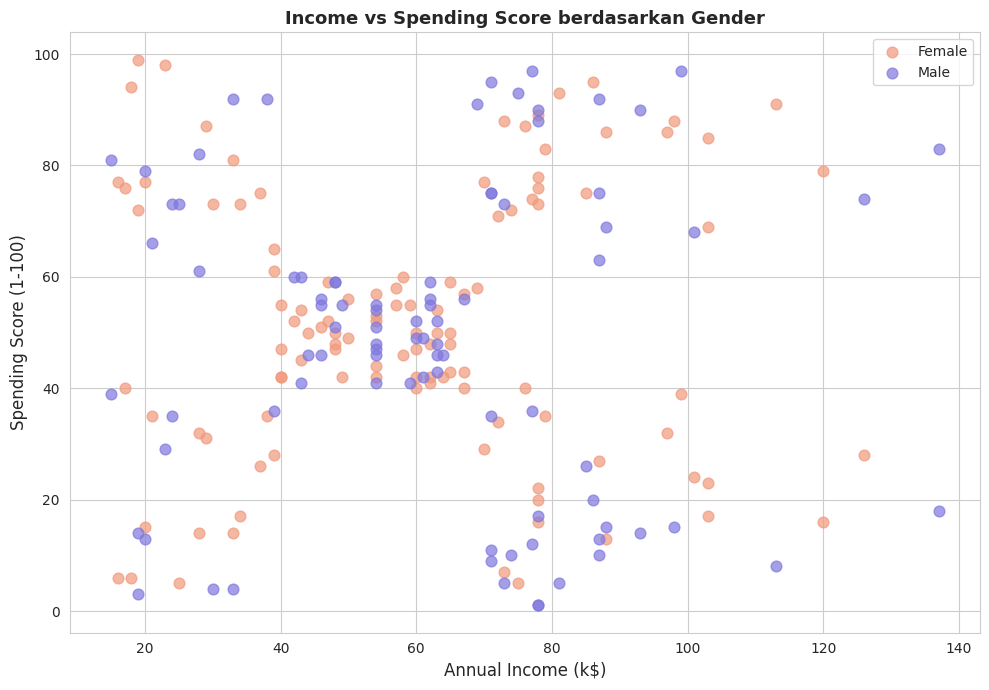


Insight EDA:
- Tidak ada missing values maupun data duplikat
- Distribusi Age dan Income cukup merata
- Terlihat pola pengelompokan natural pada scatter Income vs Spending
- Tidak ada korelasi kuat antar fitur -- cocok untuk clustering



In [10]:
# Scatter Plot Income vs Spending Score
plt.figure(figsize=(10, 7))

colors_gender = {'Male': '#7F77DD', 'Female': '#F0997B'}
for gender, group in df.groupby('Gender'):
    plt.scatter(group['Annual Income (k$)'], group['Spending Score (1-100)'],
                label=gender, color=colors_gender[gender], alpha=0.7, s=60)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Income vs Spending Score berdasarkan Gender', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("""
Insight EDA:
- Tidak ada missing values maupun data duplikat
- Distribusi Age dan Income cukup merata
- Terlihat pola pengelompokan natural pada scatter Income vs Spending
- Tidak ada korelasi kuat antar fitur -- cocok untuk clustering
""")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [11]:
# 1. Seleksi Fitur
# CustomerID tidak dipakai (hanya nomor urut)
# Gender tidak dipakai (tidak numerik)

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
df_features = df[features].copy()

print(f"Fitur yang digunakan : {features}")
print(f"Shape data fitur     : {df_features.shape}")
df_features.head()

Fitur yang digunakan : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Shape data fitur     : (200, 3)


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [12]:
# 2. Menghapus atau Menangani Data Kosong (Missing Values)
before = len(df_features)
df_features = df_features.dropna()
after = len(df_features)

removed = before - after
if removed > 0:
    print(f"Peringatan: {removed} baris dihapus karena missing values")
else:
    print(f"Tidak ada missing values -- semua {after} baris dipertahankan")

Tidak ada missing values -- semua 200 baris dipertahankan


In [13]:
# 3. Menghapus Data Duplikat
before = len(df_features)
df_features = df_features.drop_duplicates()
after = len(df_features)

removed = before - after
if removed > 0:
    print(f"Peringatan: {removed} baris duplikat dihapus")
else:
    print(f"Tidak ada data duplikat -- semua {after} baris dipertahankan")

Tidak ada data duplikat -- semua 200 baris dipertahankan


In [14]:
# 4. Deteksi dan Penanganan Outlier menggunakan IQR
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
        print(f"Kolom '{col}': {len(outliers)} outlier ditemukan")

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean

df_features = remove_outliers_iqr(df_features, features)
print(f"\nShape setelah hapus outlier: {df_features.shape}")

Kolom 'Age': 0 outlier ditemukan
Kolom 'Annual Income (k$)': 2 outlier ditemukan
Kolom 'Spending Score (1-100)': 0 outlier ditemukan

Shape setelah hapus outlier: (198, 3)


In [15]:
# 5. Normalisasi atau Standarisasi Fitur menggunakan StandardScaler
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_features)
df_scaled = pd.DataFrame(scaled_array, columns=features)

print("Statistik setelah StandardScaler:")
print(df_scaled.describe().round(3))
print()
print("Scaling berhasil -- mean = 0, std = 1")

Statistik setelah StandardScaler:
           Age  Annual Income (k$)  Spending Score (1-100)
count  198.000             198.000                 198.000
mean     0.000               0.000                   0.000
std      1.003               1.003                   1.003
min     -1.497              -1.779                  -1.916
25%     -0.764              -0.766                  -0.592
50%     -0.210               0.048                  -0.008
75%      0.720               0.714                   0.878
max      2.222               2.630                   1.900

Scaling berhasil -- mean = 0, std = 1


In [16]:
# Simpan hasil preprocessing
import os

os.makedirs('./mall_customers_preprocessing', exist_ok=True)

df_scaled.to_csv('./mall_customers_preprocessing/mall_customers_preprocessing.csv', index=False)

print("File tersimpan:")
print("  - mall_customers_preprocessing/mall_customers_preprocessing.csv")
print(f"\nShape data preprocessing: {df_scaled.shape}")
df_scaled.head()

File tersimpan:
  - mall_customers_preprocessing/mall_customers_preprocessing.csv

Shape data preprocessing: (198, 3)


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.425414,-1.779171,-0.435989
1,-1.282367,-1.779171,1.199413
2,-1.353890,-1.739447,-1.720949
3,-1.139319,-1.739447,1.043661
4,-0.567131,-1.699723,-0.397051


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
